<a href="https://colab.research.google.com/github/ruforavishnu/Project_Simulations/blob/main/12th_Standard_Maths_Chapter9_Differential_Equations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem:**

Vishnu places a cup of coffee on the desk.
Calculate how long the cup of coffee will remain hot when the fan is spinning in speed 5?

In how much time the coffee will reach half its heat? How much time the coffee will reach room temperature.

Calculate these same things if fan speed is reduced to speed 4.

In [1]:
# We are going to model the cooling of coffee using Newton’s Law of Cooling.

# now we know that the rate of change of temperature is proportional to the difference
# between the coffee temperature and room temperature.

# so we can say dT/dt = -k (T - T_room)

# Where:
# T = temperature of coffee
# T_room = room temperature
# k = cooling constant (depends on fan speed)

import sympy as sp

t = sp.symbols('t', real=True)
k = sp.symbols('k', positive=True)
T_room = 25

T = sp.Function('T')

diff_eq = sp.Eq(  sp.diff( T(t)     , t),      -k*(T(t) - T_room ) )


diff_eq

Eq(Derivative(T(t), t), -k*(T(t) - 25))

In [2]:
solution = sp.dsolve(diff_eq)

solution

Eq(T(t), C1*exp(-k*t) + 25)

**We are going to assume initial coffee temperature is 90 degree celsius**

In [3]:
T_initial = 90

C1 = sp.symbols('C1')

general_solution = solution.rhs

C_value = sp.solve(general_solution.subs(t,0)  - T_initial  ,      C1)


C_value

[65]

In [4]:
T_final = general_solution.subs(C1,  C_value[0]   )

T_final

25 + 65*exp(-k*t)

In [5]:
#now we need to define cooling constant for the fan speeds
#ok so speed5 is 0.26 and speed4 is 0.18
k1 = 0.18
k2 = 0.26



T_speed4 = T_final.subs(k,   k1)
T_speed5 = T_final.subs(k,   k2)


T_speed4, T_speed5


(25 + 65*exp(-0.18*t), 25 + 65*exp(-0.26*t))

In [6]:
import numpy as np


T4_func = sp.lambdify(t,   T_speed4,   'numpy')
T5_func = sp.lambdify(t, T_speed5,   'numpy')




**Now we need to find the heat reaching half temperature**

In [7]:
T_half  =   (90 + 25) / 2

time_half_4 = sp.solve(T_speed4 - T_half,   t)
time_half_5 = sp.solve(T_speed5 - T_half,   t)


float(time_half_4[0]),    float(time_half_5[0])



(3.850817669777474, 2.665950694461328)

**and when it reaches room temperature. means coffeee is as good as cold**

In [8]:
T_near = 26

time_room_4 = sp.solve(T_speed4 - T_near,   t)
time_room_5 = sp.solve(T_speed5 - T_near,   t)


float(time_room_4[0]),    float(time_room_5[0])



(23.191040388309094, 16.055335653444757)

**lets try to plot it so we understand it better**

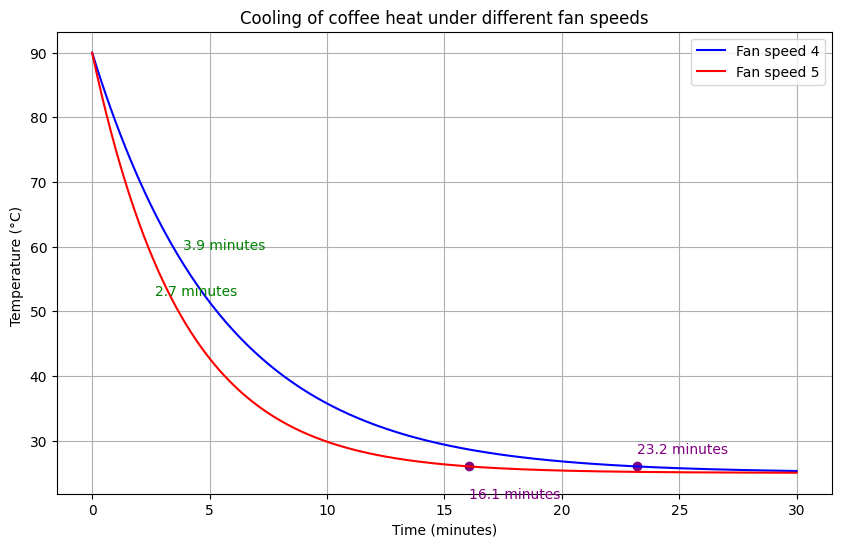

In [9]:
import matplotlib.pyplot as plt

t_vals = np.linspace(0, 30, 300)

plt.figure(figsize=(10,6))


plt.plot(t_vals,    T4_func(t_vals)   , label='Fan speed 4', color='blue')
plt.plot(t_vals,    T5_func(t_vals)   , label='Fan speed 5', color='red')


plt.scatter(  float(time_room_4[0]   ),         T_near,    color='purple')
plt.scatter(  float(time_room_5[0]   ),         T_near,    color='purple')


plt.text(   float(time_half_4[0]),     T_half+2,    f"{float(time_half_4[0]):.1f} minutes", color='green')
plt.text(   float(time_half_5[0]),     T_half-5,    f"{float(time_half_5[0]):.1f} minutes", color='green')

plt.text(   float(time_room_4[0]),     T_near+2,    f"{float(time_room_4[0]):.1f} minutes", color='purple')
plt.text(   float(time_room_5[0]),     T_near-5,    f"{float(time_room_5[0]):.1f} minutes", color='purple')



plt.xlabel('Time (minutes)')
plt.ylabel('Temperature (°C) ')
plt.title('Cooling of coffee heat under different fan speeds')
plt.legend()
plt.grid()

plt.show()



**Not at all good!! Hell, we need to find how long it will last if we turn off the fan**

In [10]:
k0 = 0.08

T_off = T_final.subs(k,  k0)
T_off_func = sp.lambdify(t,  T_off, 'numpy')



In [11]:
time_half_off = sp.solve(T_off  - T_half,    t)

time_room_off = sp.solve(T_off - T_half,   t)


float(time_half_off[0]),     float(time_room_off[0])

(8.664339756999317, 8.664339756999317)

In [12]:
t_max = max(float(time_room_4[0]), float(time_room_5[0]), float(time_room_off[0])) + 5
t_vals = np.linspace(0, t_max, 500)

In [13]:
print("Fan OFF - Half temp time:", float(time_half_off[0]))
print("Fan OFF - Room temp time:", float(time_room_off[0]))

Fan OFF - Half temp time: 8.664339756999317
Fan OFF - Room temp time: 8.664339756999317


In [14]:
import math

# constants
T0 = 90
Troom = 25
Tnear = 26

k_off = 0.08

# correct formula
time_room_off = (1 / k_off) * math.log((T0 - Troom) / (Tnear - Troom))

time_room_off

52.17984087369546

In [15]:
import math

# constants
T0 = 90
Troom = 25
T_half = (T0 + Troom) / 2   # 57.5
T_near = 26

# cooling constants
k4 = 0.18
k5 = 0.26
k_off = 0.08

# function to compute time
def cooling_time(T_target, k):
    return (1/k) * math.log((T0 - Troom)/(T_target - Troom))

# times
time_half_4 = cooling_time(T_half, k4)
time_half_5 = cooling_time(T_half, k5)
time_half_off = cooling_time(T_half, k_off)

time_room_4 = cooling_time(T_near, k4)
time_room_5 = cooling_time(T_near, k5)
time_room_off = cooling_time(T_near, k_off)

print("Half temp times:", time_half_4, time_half_5, time_half_off)
print("Room temp times:", time_room_4, time_room_5, time_room_off)

Half temp times: 3.8508176697774736 2.6659506944613276 8.664339756999317
Room temp times: 23.19104038830909 16.055335653444754 52.17984087369546


In [16]:
time_half_4 = float(time_half_4)
time_half_5 = float(time_half_5)
time_half_off = float(time_half_off)

time_room_4 = float(time_room_4)
time_room_5 = float(time_room_5)
time_room_off = float(time_room_off)

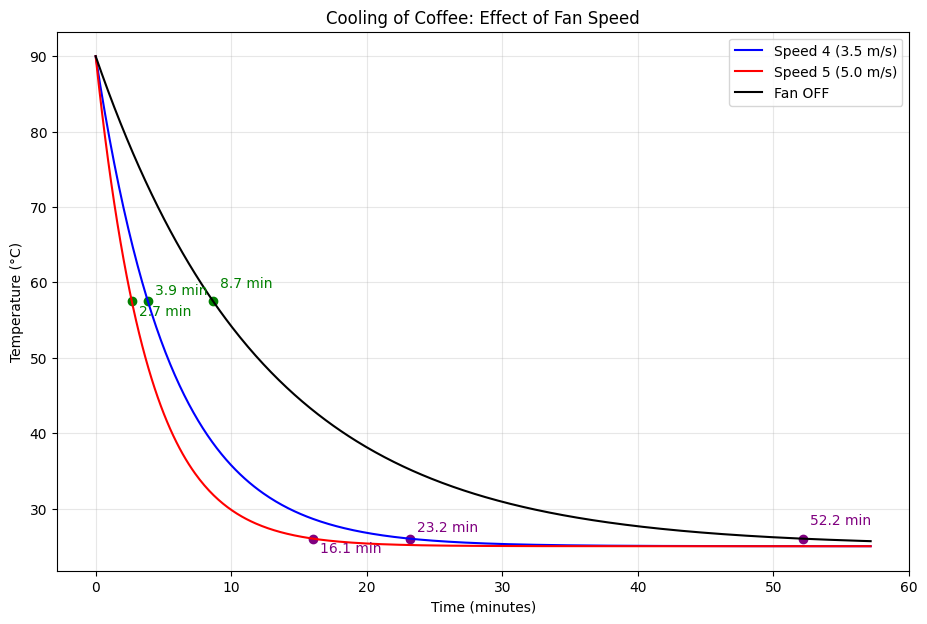

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# dynamic range so all points are visible
t_max = max(time_room_4, time_room_5, time_room_off) + 5
t_vals = np.linspace(0, t_max, 500)

plt.figure(figsize=(11,7))

# curves
plt.plot(t_vals, T4_func(t_vals), label="Speed 4 (3.5 m/s)", color='blue')
plt.plot(t_vals, T5_func(t_vals), label="Speed 5 (5.0 m/s)", color='red')
plt.plot(t_vals, T_off_func(t_vals), label="Fan OFF", color='black')

# -------- HALF TEMP (GREEN) --------
plt.scatter(time_half_4, T_half, color='green')
plt.scatter(time_half_5, T_half, color='green')
plt.scatter(time_half_off, T_half, color='green')

plt.annotate(f"{time_half_4:.1f} min", (time_half_4, T_half),
             textcoords="offset points", xytext=(5,5), color='green')

plt.annotate(f"{time_half_5:.1f} min", (time_half_5, T_half),
             textcoords="offset points", xytext=(5,-10), color='green')

plt.annotate(f"{time_half_off:.1f} min", (time_half_off, T_half),
             textcoords="offset points", xytext=(5,10), color='green')

# -------- ROOM TEMP (PURPLE) --------
plt.scatter(time_room_4, T_near, color='purple')
plt.scatter(time_room_5, T_near, color='purple')
plt.scatter(time_room_off, T_near, color='purple')

plt.annotate(f"{time_room_4:.1f} min", (time_room_4, T_near),
             textcoords="offset points", xytext=(5,5), color='purple')

plt.annotate(f"{time_room_5:.1f} min", (time_room_5, T_near),
             textcoords="offset points", xytext=(5,-10), color='purple')

plt.annotate(f"{time_room_off:.1f} min", (time_room_off, T_near),
             textcoords="offset points", xytext=(5,10), color='purple')

# labels
plt.xlabel("Time (minutes)")
plt.ylabel("Temperature (°C)")
plt.title("Cooling of Coffee: Effect of Fan Speed")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

**shit not much of a difference...**

**idea: what if we put a lid on top of the coffee mug after every sip?**

In [18]:
# lid cases
k_off_lid = 0.04
k4_lid = 0.09
k5_lid = 0.13

T_off_lid = T_final.subs(k, k_off_lid)
T4_lid = T_final.subs(k, k4_lid)
T5_lid = T_final.subs(k, k5_lid)

T_off_lid_func = sp.lambdify(t, T_off_lid, 'numpy')
T4_lid_func = sp.lambdify(t, T4_lid, 'numpy')
T5_lid_func = sp.lambdify(t, T5_lid, 'numpy')

In [19]:
time_half_off_lid = cooling_time(T_half, k_off_lid)
time_half_4_lid = cooling_time(T_half, k4_lid)
time_half_5_lid = cooling_time(T_half, k5_lid)

time_room_off_lid = cooling_time(T_near, k_off_lid)
time_room_4_lid = cooling_time(T_near, k4_lid)
time_room_5_lid = cooling_time(T_near, k5_lid)

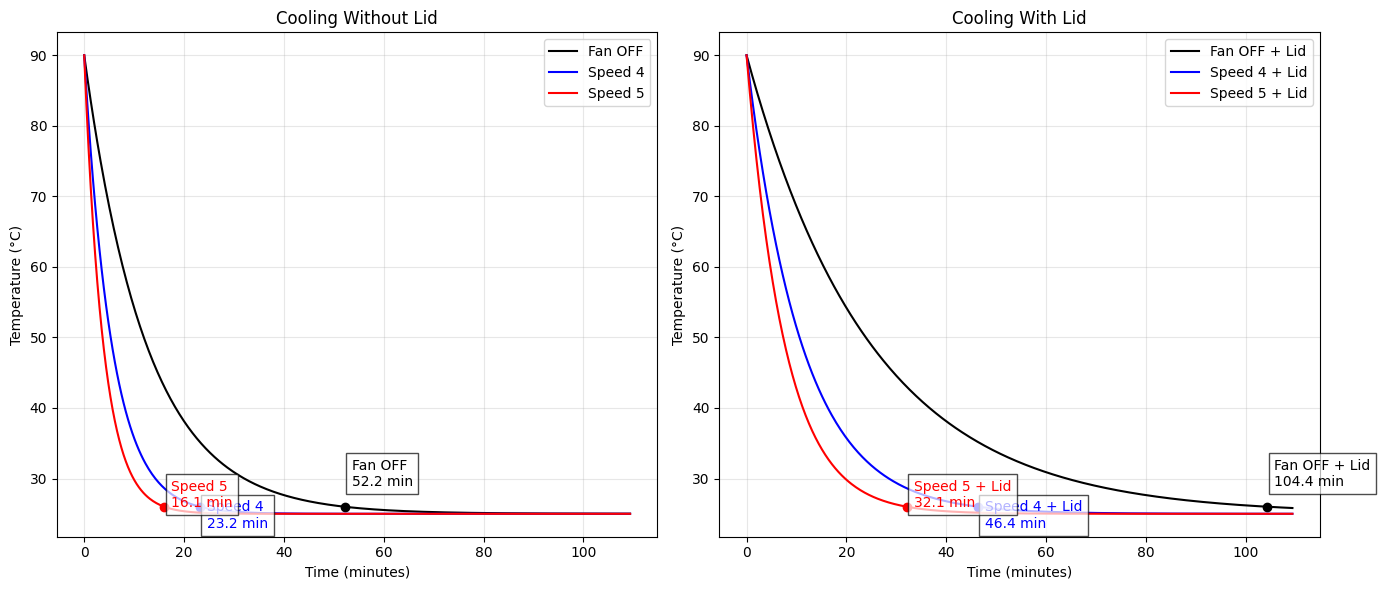

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# dynamic time range
t_max = max(
    time_room_4, time_room_5, time_room_off,
    time_room_4_lid, time_room_5_lid, time_room_off_lid
) + 5

t_vals = np.linspace(0, t_max, 500)

# create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

# =========================
# GRAPH 1 — WITHOUT LID
# =========================

ax1.plot(t_vals, T_off_func(t_vals), label="Fan OFF", color='black')
ax1.plot(t_vals, T4_func(t_vals), label="Speed 4", color='blue')
ax1.plot(t_vals, T5_func(t_vals), label="Speed 5", color='red')

offsets = {
    "Fan OFF": (5, 15),
    "Speed 4": (5, -15),
    "Speed 5": (5, 0)
}

for t_val, label, color in [
    (time_room_off, "Fan OFF", 'black'),
    (time_room_4, "Speed 4", 'blue'),
    (time_room_5, "Speed 5", 'red')
]:
    ax1.scatter(t_val, T_near, color=color)
    dx, dy = offsets[label]

    ax1.annotate(f"{label}\n{t_val:.1f} min",
                 (t_val, T_near),
                 textcoords="offset points",
                 xytext=(dx, dy),
                 color=color,
                 bbox=dict(facecolor='white', alpha=0.7))

ax1.set_title("Cooling Without Lid")
ax1.set_xlabel("Time (minutes)")
ax1.set_ylabel("Temperature (°C)")
ax1.legend()
ax1.grid(alpha=0.3)


# =========================
# GRAPH 2 — WITH LID
# =========================

ax2.plot(t_vals, T_off_lid_func(t_vals), label="Fan OFF + Lid", color='black')
ax2.plot(t_vals, T4_lid_func(t_vals), label="Speed 4 + Lid", color='blue')
ax2.plot(t_vals, T5_lid_func(t_vals), label="Speed 5 + Lid", color='red')

offsets_lid = {
    "Fan OFF + Lid": (5, 15),
    "Speed 4 + Lid": (5, -15),
    "Speed 5 + Lid": (5, 0)
}

for t_val, label, color in [
    (time_room_off_lid, "Fan OFF + Lid", 'black'),
    (time_room_4_lid, "Speed 4 + Lid", 'blue'),
    (time_room_5_lid, "Speed 5 + Lid", 'red')
]:
    ax2.scatter(t_val, T_near, color=color)
    dx, dy = offsets_lid[label]

    ax2.annotate(f"{label}\n{t_val:.1f} min",
                 (t_val, T_near),
                 textcoords="offset points",
                 xytext=(dx, dy),
                 color=color,
                 bbox=dict(facecolor='white', alpha=0.7))

ax2.set_title("Cooling With Lid")
ax2.set_xlabel("Time (minutes)")
ax2.set_ylabel("Temperature (°C)")
ax2.legend()
ax2.grid(alpha=0.3)


# layout
plt.tight_layout()
plt.show()

**hmmmm... athra pora...hell whatever**